
# Week 1 Lab – Linear Regression with One Feature (No Vectorization)

In this lab we will work with a very simple version of supervised learning:

- Our data consists of pairs $(x^{(i)}, y^{(i)})$, where $x^{(i)}$ is one feature and $y^{(i)}$ is the target.
- We will use a **linear regression model** with one feature.
- We will measure how good the model is using a **cost function** based on mean squared error.
- We will train the model with **gradient descent**.
- In all code, we will avoid NumPy vectorization and use **explicit Python loops**.



## 0. Theory Refresher

### 0.1 Linear Regression (One Feature)

We assume there is (approximately) a linear relationship between the input $x$ and the output $y$.  
Our model (or hypothesis) is a function that depends on the parameters $w$ and $b$:

$$
f_{w,b}(x) = wx + b
$$

- $w$ is the **slope**: how much $f_{w,b}(x)$ changes when $x$ increases by 1.
- $b$ is the **intercept**: the value of $f_{w,b}(x)$ when $x = 0$.
- For a dataset with $m$ examples, we write the $i$-th example as $(x^{(i)}, y^{(i)})$.  
  The prediction for that example is:
  $$
  \hat{y}^{(i)} = f_{w,b}(x^{(i)}) = w x^{(i)} + b
  $$



### 0.2 Cost Function (Mean Squared Error)

We need a way to measure how well a particular line (given by $w$ and $b$) fits the data.

We use the **mean squared error (MSE)** cost function:

$$
J(w,b) = \frac{1}{2m} \sum_{i=1}^{m} \big( \hat{y}^{(i)} - y^{(i)} \big)^2
       = \frac{1}{2m} \sum_{i=1}^{m} \big( f_{w,b}(x^{(i)}) - y^{(i)} \big)^2
$$

- The term $(\hat{y}^{(i)} - y^{(i)})$ is the **error** for example $i$.
- We square the error so that positive and negative errors do not cancel out, and to penalize large errors more.
- The factor $\frac{1}{2m}$ is for mathematical convenience when taking derivatives.

Our goal is to find values of $w$ and $b$ that **minimize** $J(w,b)$.



### 0.3 Gradient Descent

To minimize $J(w,b)$, we use **gradient descent**.  
The idea is to start with some initial $(w,b)$ and repeatedly update them in the direction that decreases the cost.

We compute the partial derivatives:

$$
\frac{\partial J}{\partial w} = \frac{1}{m} \sum_{i=1}^{m} \big( f_{w,b}(x^{(i)}) - y^{(i)} \big) x^{(i)}
$$

$$
\frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} \big( f_{w,b}(x^{(i)}) - y^{(i)} \big)
$$

Given a **learning rate** $\alpha > 0$, we update:

$$
w := w - \alpha \frac{\partial J}{\partial w}, \qquad
b := b - \alpha \frac{\partial J}{\partial b}
$$

We repeat these updates many times. If $\alpha$ is chosen well, the cost $J(w,b)$ will decrease and $(w,b)$ will move toward values that fit the data.


## 1. Setup

In [1]:
# Install required libraries (run this once if needed)
%pip install numpy matplotlib


   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   -- ------------------------------------- 0.8/12.6 MB 4.2 MB/s eta 0:00:03
   --- ------------------------------------ 1.0/12.6 MB 2.0 MB/s eta 0:00:06
   --- ------------------------------------ 1.0/12.6 MB 2.0 MB/s eta 0:00:06
   ---- ----------------------------------- 1.3/12.6 MB 1.5 MB/s eta 0:00:08
   ---- ----------------------------------- 1.3/12.6 MB 1.5 MB/s eta 0:00:08
   ---- ----------------------------------- 1.6/12.6 MB 1.1 MB/s eta 0:00:11
   ---- ----------------------------------- 1.6/12.6 MB 1.1 MB/s eta 0:00:11
   ------ --------------------------------- 2.1/12.6 MB 1.2 MB/s eta 0:00:10
   -------- ------------------------------- 2.6/12.6 MB 1.3 MB/s eta 0:00:08
   --------- ------------------------------ 3.1/12.6 MB 1.4 MB/s eta 0:00:07
   ----------- ---------------------------- 3.7/12.6 MB 1.5 MB/s eta 0:00:06
   ----------

In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt


## 2. Create a Simple Dataset

We will create a small synthetic dataset using Python's built-in `random` module.

The data roughly follows this linear relationship:

$$
y \approx 3x + 2 + \text{noise}
$$

Each point is a pair $(x^{(i)}, y^{(i)})$ with **one feature** $x^{(i)}$.

The noise makes the points more realistic: instead of falling exactly on one line, some points are above the line and some are below it. We will control the amount of noise with a variable called `noise_factor`.


In [26]:
# We set the random seed so students get the same dataset every time.
# Try changing this number later and see how the points change.
random.seed(0)

# m is the number of training examples.
m = 50

# These are the true values used to create the example data.
# Gradient descent will try to recover values close to these.
true_w = 3.0
true_b = 2.0

# This controls how noisy the data is.
# Try values like 0, 2, 6, or 10.
noise_factor = 10

# x contains the input values.
# We create m values evenly spaced between 0 and 10.
x = []
for i in range(m):
    x_value = i * 10 / (m - 1)
    x.append(x_value)

# y contains the target values.
# For each x, we start from the line y = 3x + 2,
# then add random noise.
y = []
for i in range(m):
    # random.uniform(-1, 1) gives a number between -1 and 1.
    # Multiplying by noise_factor controls how large the noise can be.
    noise = random.uniform(-1, 1) * noise_factor

    #print(noise)

    y_value = true_w * x[i] + true_b + noise
    y.append(y_value)

print(f"Number of examples m = {m}")
print("First 10 x values:", x[:10])
print("First 10 y values:", y[:10])


Number of examples m = 50
First 10 x values: [0.0, 0.20408163265306123, 0.40816326530612246, 0.6122448979591837, 0.8163265306122449, 1.0204081632653061, 1.2244897959183674, 1.4285714285714286, 1.6326530612244898, 1.836734693877551]
First 10 y values: [8.888437030500963, 7.771332956765233, 1.6359214125352675, -0.9849303002631817, 4.674474019208905, 3.1599072388042044, 11.349441168450554, 2.3519688072928346, 6.429898266720586, 9.177844870733278]


### 2.1 Visualize the Data

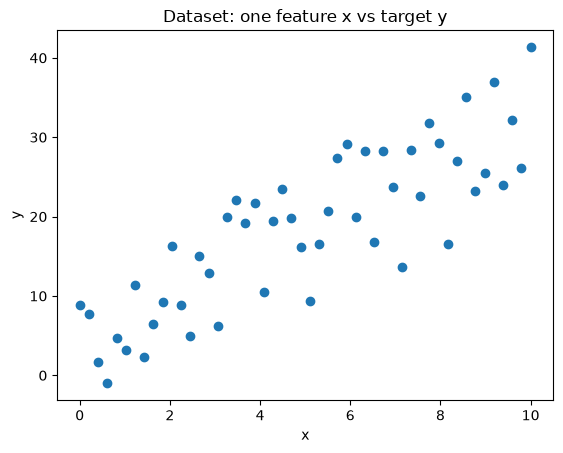

In [25]:
# Create a new empty figure.
plt.figure()

# Draw one point for each pair (x[i], y[i]).
# A scatter plot is useful when we want to see individual data points.
plt.scatter(x, y)

# Add labels so the axes are easy to understand.
plt.xlabel("x")
plt.ylabel("y")

# Add a title to describe what the plot shows.
plt.title("Dataset: one feature x vs target y")

# Display the plot.
plt.show()



## 3. Linear Regression Model with One Feature

We use the model (hypothesis function):

$$
f_{w,b}(x^{(i)}) = w x^{(i)} + b
$$

where:
- $w$ is the slope,
- $b$ is the intercept.


In [ ]:
def predict(x_list, w, b):
    """Compute predicted y values for each x value."""
    y_hat_list = []

    for i in range(len(x_list)):
        # Take one input value from the list.
        x_i = x_list[i]

        # Apply the linear model: f_wb(x) = w*x + b.
        prediction = w * x_i + b

        # Store the prediction so we can use it later.
        y_hat_list.append(prediction)

    return y_hat_list

# Try a very simple line first: y = 0*x + 0.
w_test = 1.0
b_test = 0.0
y_hat_test = predict(x, w_test, b_test)

print("Predictions with w=0, b=0:", y_hat_test)


Predictions with w=0, b=0: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]



## 4. Cost Function $J(w,b)$

We define the **mean squared error** cost function:

$$
J(w,b) = \frac{1}{2m} \sum_{i=1}^{m} \big( \hat{y}^{(i)} - y^{(i)} \big)^2
$$

$$
J(w,b) = \frac{1}{2m} \sum_{i=1}^{m} \big( f_{w,b}(x^{(i)}) - y^{(i)} \big)^2
$$

This measures how well the model $f_{w,b}(x) = w x + b$ fits the data.


In [33]:
def compute_cost(x_list, y_list, w, b):
    """Compute the cost J(w,b) using explicit loops."""
    m_local = len(x_list)
    total_squared_error = 0.0

    for i in range(m_local):
        # Step 1: make a prediction for example i.
        prediction = w * x_list[i] + b

        # Step 2: compare the prediction with the real target value.
        error = prediction - y_list[i]

        # Step 3: square the error and add it to the total.
        total_squared_error = total_squared_error + error ** 2

    # The 2 in the denominator makes derivatives cleaner later.
    cost = total_squared_error / (2 * m_local)
    return cost

print("Cost with w=1, b=0:", compute_cost(x, y, w_test, b_test))


Cost with w=1, b=0: 220.41492648571878


### 4.1 Visualize the Cost Function as a Surface

We can visualize how $J(w,b)$ changes as we vary $w$ and $b$.

This plotting cell is a little more technical because 3D plots need grid data. The important idea is simple: for many different values of $w$ and $b$, we compute the cost and draw the result as a surface.


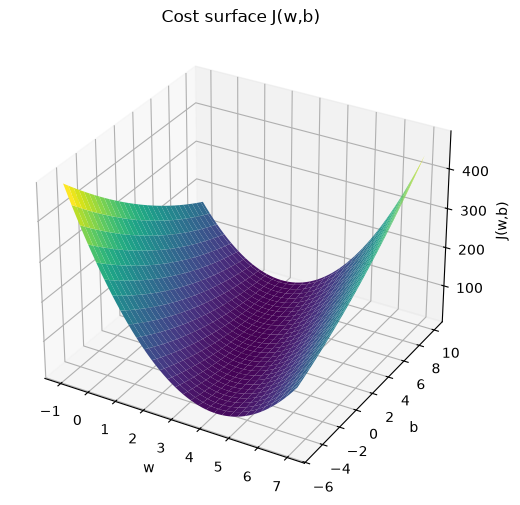

In [34]:
# These imports are used only for the 3D visualization.
# Axes3D allows Matplotlib to draw 3D plots.
# cm gives us color maps, which help us color the surface by height.
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

# We want to see how the cost changes for many possible values of w and b.
# These lists contain the values we will try.
# NumPy is used here only to create evenly spaced values for the plot.
w_values = [float(v) for v in np.linspace(-1.0, 7.0, 60)]
b_values = [float(v) for v in np.linspace(-5.0, 10.0, 60)]

# To draw a surface, Matplotlib needs three grids:
# W: the w value at each point on the surface
# B: the b value at each point on the surface
# J_vals: the cost J(w,b) at each point on the surface
W = []
B = []
J_vals = []

# The outer loop goes through possible values of b.
# Each value of b becomes one row in the surface grid.
for i in range(len(b_values)):
    row_W = []
    row_B = []
    row_J = []

    # The inner loop goes through possible values of w.
    # Together, one b value and one w value define one point on the grid.
    for j in range(len(w_values)):
        w_curr = w_values[j]
        b_curr = b_values[i]

        # Save the current w and b values for this grid point.
        row_W.append(w_curr)
        row_B.append(b_curr)

        # Compute the cost for this pair of parameters.
        # This answers: how good is the line y = w_curr*x + b_curr?
        cost_curr = compute_cost(x, y, w_curr, b_curr)
        row_J.append(cost_curr)

    # After finishing all w values for this b value,
    # add the completed row to each grid.
    W.append(row_W)
    B.append(row_B)
    J_vals.append(row_J)

# Matplotlib's plot_surface function expects NumPy arrays,
# so we convert our lists of lists into arrays.
W_arr = np.array(W)
B_arr = np.array(B)
J_arr = np.array(J_vals)

# Create a new figure for the 3D plot.
# figsize=(8, 6) controls the size of the figure in inches:
# 8 inches wide and 6 inches tall.
fig = plt.figure(figsize=(8, 6))

# Add one set of 3D axes to the figure.
# 111 means: 1 row, 1 column, first plot.
# projection="3d" tells Matplotlib that these axes should be 3D.
ax = fig.add_subplot(111, projection="3d")

# Draw the surface.
# The first three arguments are the x, y, and z values of the surface:
# W_arr gives the w-axis values, B_arr gives the b-axis values,
# and J_arr gives the height, which is the cost J(w,b).
# cmap=cm.viridis chooses the color palette for the surface.
# linewidth=0 removes the grid lines between small surface squares.
# antialiased=True smooths the edges so the surface looks cleaner.
# Low areas represent better choices of w and b.
ax.plot_surface(W_arr, B_arr, J_arr, cmap=cm.viridis, linewidth=0, antialiased=True)

# Label each axis so we know what the dimensions represent.
# set_xlabel, set_ylabel, and set_zlabel control the text shown near each axis.
ax.set_xlabel("w")
ax.set_ylabel("b")
ax.set_zlabel("J(w,b)")

# Add a title above the plot.
ax.set_title("Cost surface J(w,b)")

# Display the plot.
plt.show()



## 5. Gradient Descent

We use **gradient descent** with the update rules:

$$
\frac{\partial J}{\partial w} = \frac{1}{m} \sum_{i=1}^{m} \big( f_{w,b}(x^{(i)}) - y^{(i)} \big) x^{(i)}, \quad
\frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} \big( f_{w,b}(x^{(i)}) - y^{(i)} \big)
$$

Update:

$$
w := w - \alpha \frac{\partial J}{\partial w}, \quad
b := b - \alpha \frac{\partial J}{\partial b}
$$


In [ ]:
def compute_gradients(x_list, y_list, w, b):
    """Compute dJ/dw and dJ/db using explicit loops."""
    m_local = len(x_list)
    sum_dw = 0.0
    sum_db = 0.0

    for i in range(m_local):
        # Step 1: make a prediction with the current w and b.
        prediction = w * x_list[i] + b

        # Step 2: compute the error for this example.
        error = prediction - y_list[i]

        # Step 3: add this example's contribution to each derivative.
        sum_dw = sum_dw + error * x_list[i]
        sum_db = sum_db + error

    # Step 4: average over all training examples.
    dj_dw = sum_dw / m_local
    dj_db = sum_db / m_local

    return dj_dw, dj_db

dj_dw_test, dj_db_test = compute_gradients(x, y, 0, 0)
print("Gradients at w=1, b=0:", dj_dw_test, dj_db_test)


Gradients at w=0, b=0: -75.97450844486855 -9.386989412689008


### 5.1 Implement the Gradient Descent Loop

In [31]:
def gradient_descent(x_list, y_list, w_init, b_init, alpha, num_iterations):
    """Run gradient descent and keep track of the cost after each update."""
    w = w_init
    b = b_init
    history_iterations = []
    history_costs = []

    for i in range(num_iterations):
        # Compute the direction of steepest increase of the cost.
        dj_dw, dj_db = compute_gradients(x_list, y_list, w, b)

        # Move in the opposite direction to reduce the cost.
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        # Save the cost so we can plot learning progress later.
        cost = compute_cost(x_list, y_list, w, b)
        history_iterations.append(i)
        history_costs.append(cost)

        # Print progress about 10 times during training.
        if i % max(1, (num_iterations // 10)) == 0:
            print(f"Iteration {i:4d}: w={w:7.4f}, b={b:7.4f}, cost={cost:8.4f}")

    return w, b, history_iterations, history_costs

# A smaller learning rate is useful here because x values go up to 30.
# With larger x values, the gradients can also be larger.
alpha = 0.001
num_iterations = 10000

w_init = 1.0
b_init = 1.0

w_learned, b_learned, it_hist, cost_hist = gradient_descent(x, y, w_init, b_init, alpha, num_iterations)

print("\nLearned parameters:")
print("w =", w_learned)
print("b =", b_learned)


Iteration    0: w= 1.7730, b= 1.1139, cost= 41.4089
Iteration 2000: w= 3.3474, b= 0.6510, cost=  3.2103
Iteration 4000: w= 3.3481, b= 0.6466, cost=  3.2103
Iteration 6000: w= 3.3481, b= 0.6465, cost=  3.2103
Iteration 8000: w= 3.3481, b= 0.6465, cost=  3.2103
Iteration 10000: w= 3.3481, b= 0.6465, cost=  3.2103
Iteration 12000: w= 3.3481, b= 0.6465, cost=  3.2103
Iteration 14000: w= 3.3481, b= 0.6465, cost=  3.2103
Iteration 16000: w= 3.3481, b= 0.6465, cost=  3.2103
Iteration 18000: w= 3.3481, b= 0.6465, cost=  3.2103

Learned parameters:
w = 3.348090606328823
b = 0.646536381044896


### 5.2 Plot the Cost over Iterations

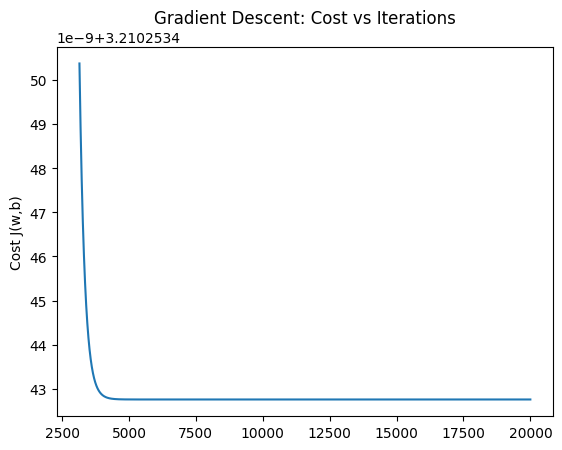

In [32]:
plt.figure()
plt.plot(it_hist, cost_hist)
plt.xlabel("Iteration")
plt.ylabel("Cost J(w,b)")
plt.title("Gradient Descent: Cost vs Iterations")
plt.show()


### 5.3 Visualize the Fitted Line

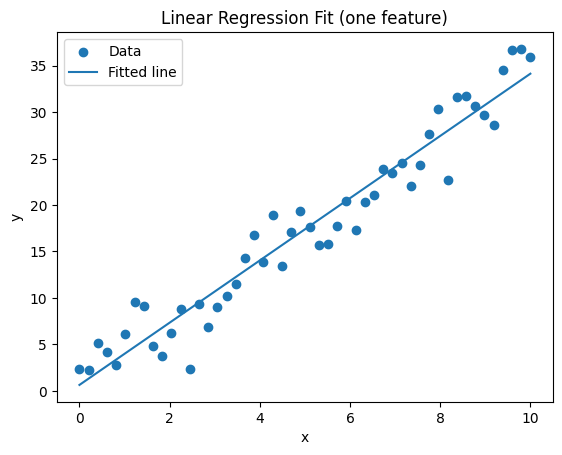

In [33]:

plt.figure()
plt.scatter(x, y, label="Data")
y_pred = predict(x, w_learned, b_learned)
plt.plot(x, y_pred, label="Fitted line")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear Regression Fit (one feature)")
plt.legend()
plt.show()


## 6. Exercises (for You to Try)

1. **Change the learning rate $\alpha$**:
   - Try values like `0.0001`, `0.001`, `0.01`.
   - What happens to the speed of convergence? Does the algorithm diverge for some values?

2. **Change the number of iterations**:
   - Try `num_iterations = 100`, `500`, `2000`.
   - How does the final cost change?

3. **Try different initial values** for `w_init` and `b_init`:
   - Does gradient descent still converge to similar values?

4. **Change the noise factor**:
   - Go back to the cell where we define `noise_factor`.
   - Try values like `0`, `2`, `6`, or `10`.
   - How does the fitted line change when the data is more or less noisy?

5. **(Optional) Manual check**:
   - Pick some values of $w$ and $b$, compute $J(w,b)$ using `compute_cost`,
   - Plot the line and see visually if a smaller cost corresponds to a better fit.
